2026-07-04 16:43:28.937 | INFO     | __main__:node_a:12 - 当前步骤: 1
2026-07-04 16:43:28.939 | INFO     | __main__:node_b:17 - 当前步骤: 2
2026-07-04 16:43:28.941 | INFO     | __main__:node_c:22 - 当前步骤: 2
2026-07-04 16:43:28.944 | INFO     | __main__:node_d:27 - 当前步骤: 3
2026-07-04 16:43:28.944 | INFO     | __main__:node_e:32 - 当前步骤: 3
2026-07-04 16:43:28.946 | INFO     | __main__:node_e:32 - 当前步骤: 4


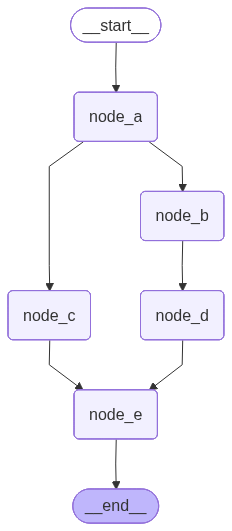

In [1]:
from typing import TypedDict
from loguru import logger
from langchain_core.runnables import RunnableConfig
from langgraph.graph import StateGraph, START, END

#1. 定义状态
class EmptyState(TypedDict):
    pass
#2. 声明节点
def node_a(state:EmptyState,config:RunnableConfig) -> EmptyState:
    cur_step = config["metadata"]["langgraph_step"]
    logger.info(f"当前步骤: {cur_step}")
    return {}

def node_b(state:EmptyState,config:RunnableConfig) -> EmptyState:
    cur_step = config["metadata"]["langgraph_step"]
    logger.info(f"当前步骤: {cur_step}")
    return {}

def node_c(state:EmptyState,config:RunnableConfig) -> EmptyState:
    cur_step = config["metadata"]["langgraph_step"]
    logger.info(f"当前步骤: {cur_step}")
    return {}

def node_d(state:EmptyState,config:RunnableConfig) -> EmptyState:
    cur_step = config["metadata"]["langgraph_step"]
    logger.info(f"当前步骤: {cur_step}")
    return {}

def node_e(state:EmptyState,config:RunnableConfig) -> EmptyState:
    cur_step = config["metadata"]["langgraph_step"]
    logger.info(f"当前步骤: {cur_step}")
    return {}

#3. 构建图
builder = StateGraph(state_schema=EmptyState)
builder.add_node("node_a",node_a)
builder.add_node("node_b",node_b)
builder.add_node("node_c",node_c)
builder.add_node("node_d",node_d)
builder.add_node("node_e",node_e)

builder.add_edge(START,"node_a")
builder.add_edge("node_a","node_b")
builder.add_edge("node_a","node_c")
builder.add_edge("node_b","node_d")
# 或节点扇入关系
builder.add_edge("node_c","node_e")
builder.add_edge("node_d","node_e")
# 与节点扇入关系
# builder.add_edge(["node_c","node_d"],"node_e")

builder.add_edge("node_e",END)

graph = builder.compile()
graph.invoke({})

from IPython.display import display
display(graph)